<a href="https://colab.research.google.com/github/jaiindian1/Health_plus/blob/main/music_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import kagglehub
import pandas as pd
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- STEP 1 & 2: REFINED UNIVERSAL LOADING ---
dataset_name = "gtzan-dataset-music-genre-classification"
csv_filename = 'features_3_sec.csv'
csv_path = None

print("🔍 Searching for the Data Matrix...")

# 1. CHECK KAGGLE DIRECTORIES (Precise Search)
if os.path.exists('/kaggle/input'):
    for dirname, _, filenames in os.walk('/kaggle/input'):
        if csv_filename in filenames:
            csv_path = os.path.join(dirname, csv_filename)
            print(f"✅ Found data in Kaggle: {csv_path}")
            break

# 2. CHECK LOCAL ZIP (If Kaggle check failed)
if not csv_path and os.path.exists(f'{dataset_name}.zip'):
    with zipfile.ZipFile(f'{dataset_name}.zip', 'r') as zip_ref:
        zip_ref.extractall('music_project')
    csv_path = 'music_project/Data/features_3_sec.csv'
    print("✅ Found and extracted local ZIP file.")

# 3. USE KAGGLEHUB (Final Fallback)
if not csv_path:
    print("ℹ️ Local/Kaggle folders not found. Calling kagglehub...")
    path = kagglehub.dataset_download(f"andradaolteanu/{dataset_name}")
    csv_path = os.path.join(path, 'Data', csv_filename)
    print(f"✅ Data downloaded via kagglehub.")

# --- THE "OR" CHECK & LOADING ---
if csv_path and os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    # THE SNIPER CLEANING
    df = df[df['filename'] != 'jazz.00054.wav'].copy()
    df = df.drop(columns=['filename', 'length'])
    print(f"🚀 Matrix Successfully Created! Shape: {df.shape}")

    # --- STEP 3: LABEL ENCODING ---
    encoder = LabelEncoder()
    df['label'] = encoder.fit_transform(df['label'])
    print("✅ Step 3: Labels Encoded.")

    # --- STEP 4: SCALING & SPLITTING ---
    X = df.drop('label', axis=1)
    y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    print("✅ Step 4: Data Scaled and Split. Ready for Model Building!")

else:
    print("❌ CRITICAL ERROR: Could not find 'features_3_sec.csv'. Please check if the dataset is added to the notebook.")

🔍 Searching for the Data Matrix...
ℹ️ Local/Kaggle folders not found. Calling kagglehub...
Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
✅ Data downloaded via kagglehub.
🚀 Matrix Successfully Created! Shape: (9990, 58)
✅ Step 3: Labels Encoded.
✅ Step 4: Data Scaled and Split. Ready for Model Building!


🌲 Training the Random Forest... The T4 is ready.
✅ Step 5: Model Training Complete.

🎯 FINAL MODEL ACCURACY: 87.34%


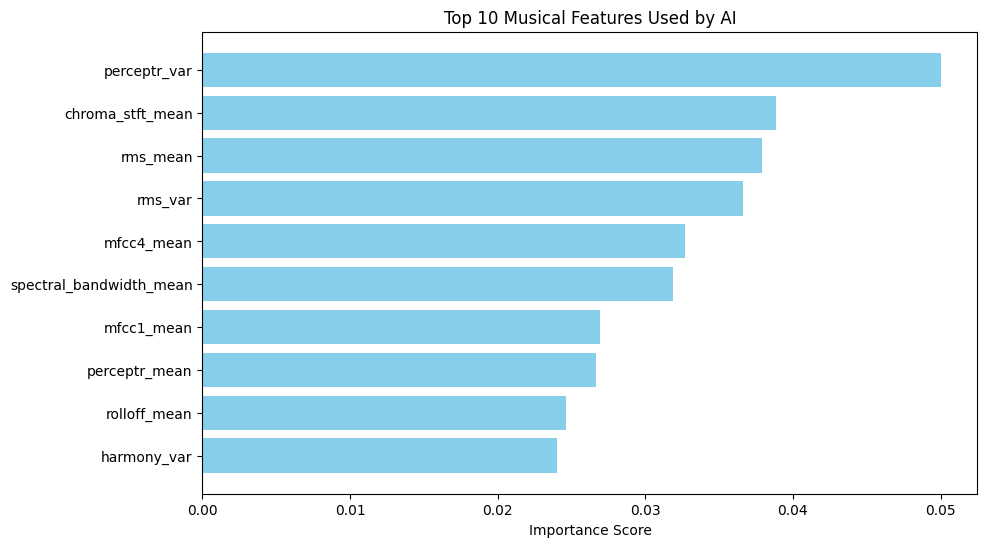

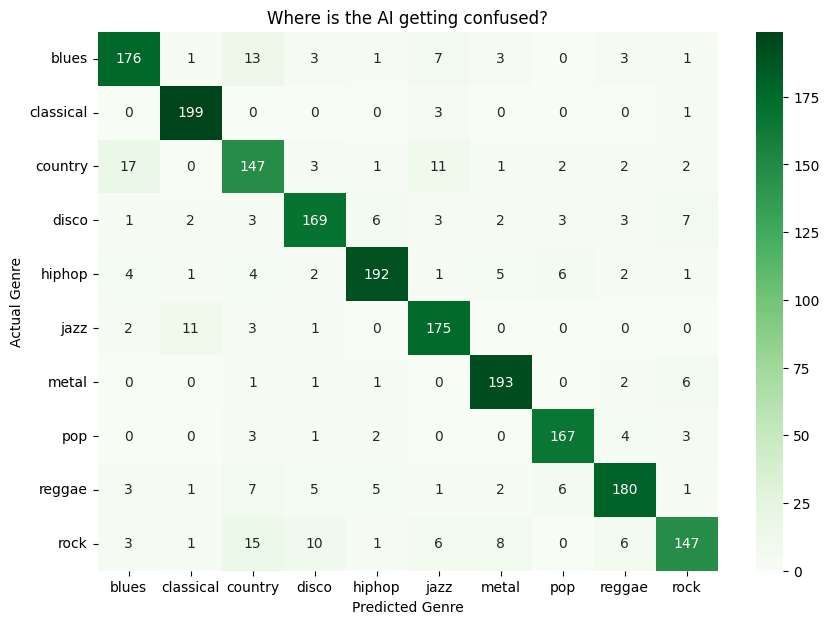

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 5: MODEL TRAINING ---
# We use 100 decision trees to ensure high stability and confidence
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("🌲 Training the Random Forest... The T4 is ready.")
model.fit(X_train, y_train)
print("✅ Step 5: Model Training Complete.")

# --- STEP 6: EVALUATION ---
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"\n🎯 FINAL MODEL ACCURACY: {accuracy:.2f}%")

# --- STEP 7: FEATURE IMPORTANCE (The Mentor's View) ---
# This shows us what the AI actually cares about in the music
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Musical Features Used by AI')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importance Score')
plt.show()

# --- STEP 8: THE CONFUSION MATRIX ---
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.title('Where is the AI getting confused?')
plt.show()

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# --- PREP FOR NEURAL NETWORK ---
# NNs need the labels to be 'One-Hot Encoded' (a matrix of 0s and 1s)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# --- STEP 5: MODEL ARCHITECTURE ---
model_nn = Sequential([
    # Layer 1: Input layer (58 features)
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3), # 'Sniper' trick to prevent memorization

    # Layer 2: Hidden layer
    Dense(256, activation='relu'),
    Dropout(0.3),

    # Layer 3: Hidden layer
    Dense(128, activation='relu'),

    # Layer 4: Output layer (10 genres)
    Dense(10, activation='softmax') # Softmax gives us probabilities
])

# --- STEP 6: COMPILING & TRAINING ---
model_nn.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

print("🧠 Training the Neural Network Brain... This uses the T4 power!")
history = model_nn.fit(X_train, y_train_cat,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test_cat),
                    verbose=1)

# --- STEP 7: FINAL SCORE ---
test_loss, test_acc = model_nn.evaluate(X_test, y_test_cat)
print(f"\n🎯 NEURAL NETWORK ACCURACY: {test_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🧠 Training the Neural Network Brain... This uses the T4 power!
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5692 - loss: 1.2148 - val_accuracy: 0.7222 - val_loss: 0.8182
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7173 - loss: 0.8200 - val_accuracy: 0.7553 - val_loss: 0.7034
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7606 - loss: 0.6866 - val_accuracy: 0.7953 - val_loss: 0.6009
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7958 - loss: 0.5860 - val_accuracy: 0.8223 - val_loss: 0.5248
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8224 - loss: 0.5003 - val_accuracy: 0.8443 - val_loss: 0.4815
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8403 - loss: 0.4635 - val_accuracy: 0.8544 - val_loss: 0.4659
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8597 - loss: 0.4140 - val_accuracy: 0.8604 - val_loss: 0.4541
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 